# Task 2 — How Attention Works

### 1. The Query-Key-Value (QKV) Framework
Modern attention mechanisms use a database search analogy consisting of three vectors: **Queries ($Q$)**, **Keys ($K$)**, and **Values ($V$)**.

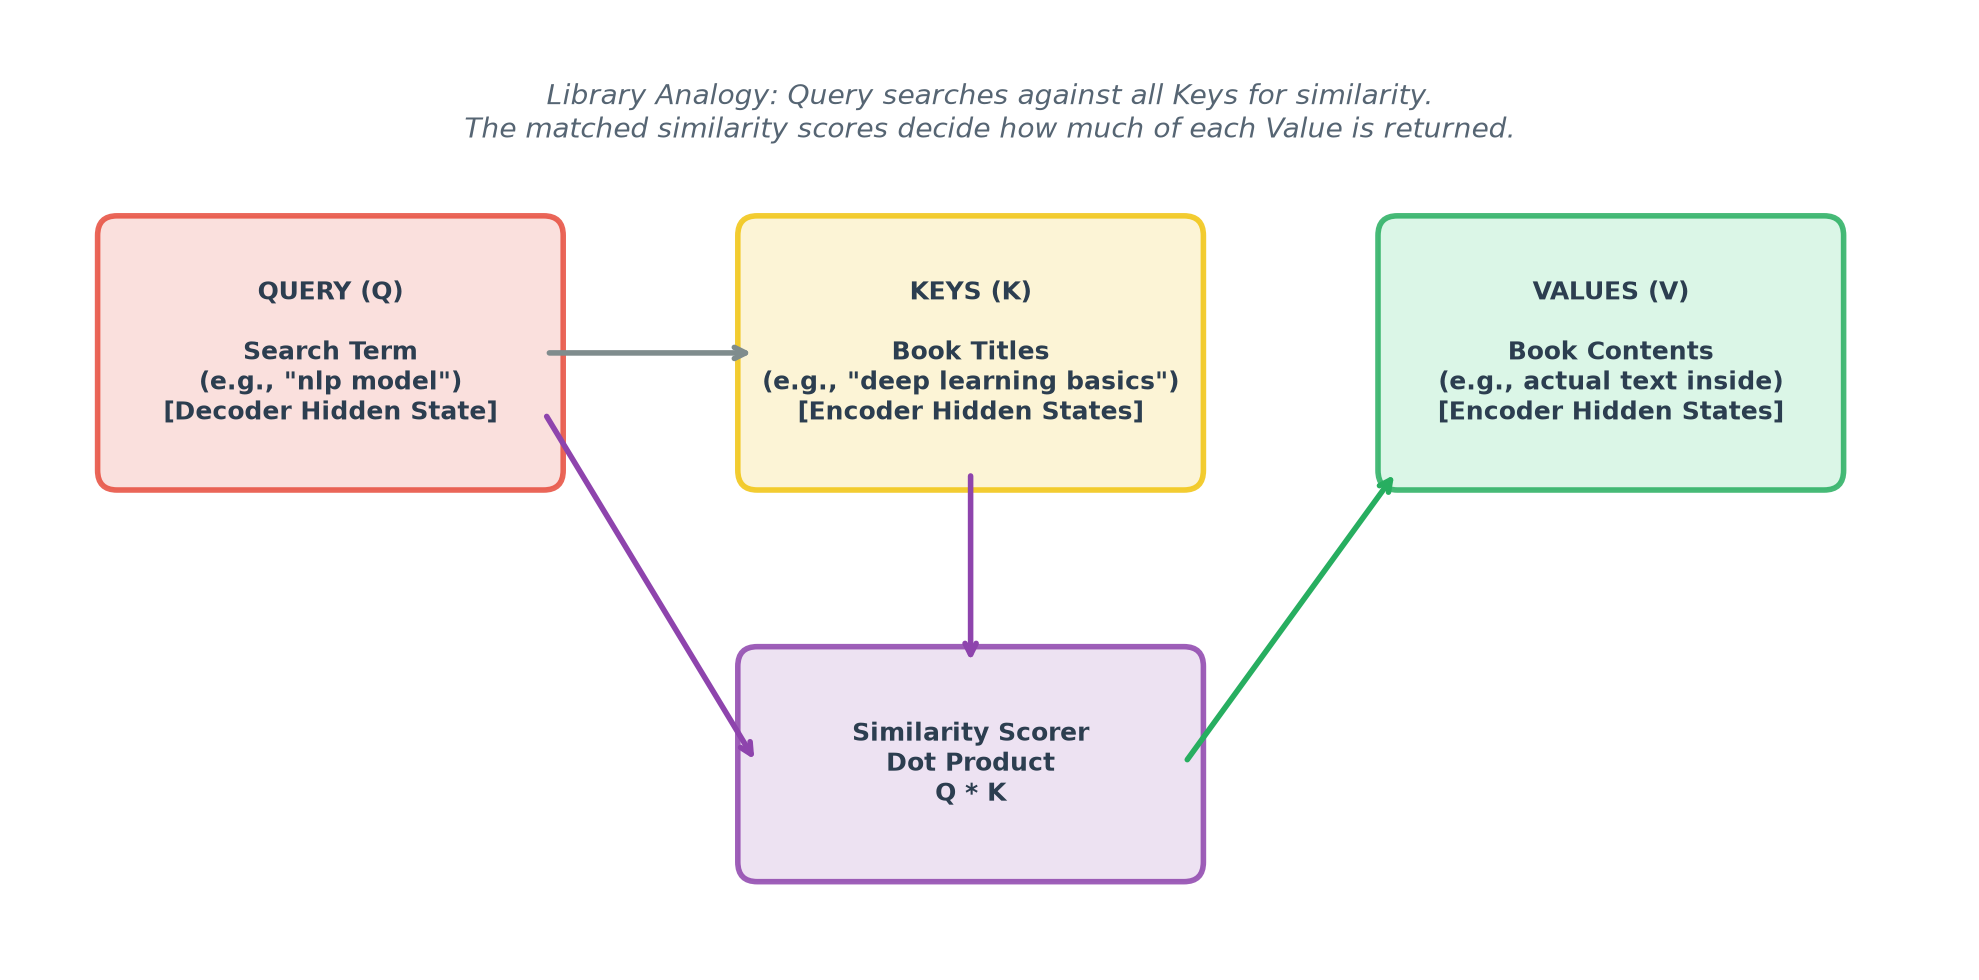

To understand this conceptually, think of looking up a video on YouTube:
- **Query ($Q$)**: The text you type into the search bar (e.g. "how to build a recurrent network from scratch"). This represents the target word context we want to generate.
- **Keys ($K$)**: The video titles, tags, and metadata in YouTube's database. This represents the indexed locations of the source text tokens.
- **Values ($V$)**: The actual video content that you watch. This represents the semantic context of the source tokens.

To fetch the best video, the database engine compares your Query against all database Keys to calculate a similarity score. These similarity scores are normalized using Softmax into weights, which are then multiplied by the corresponding Values to generate the final output.

---

### 2. The Scaled Dot-Product Attention Pipeline
Let's trace how attention is calculated step-by-step:

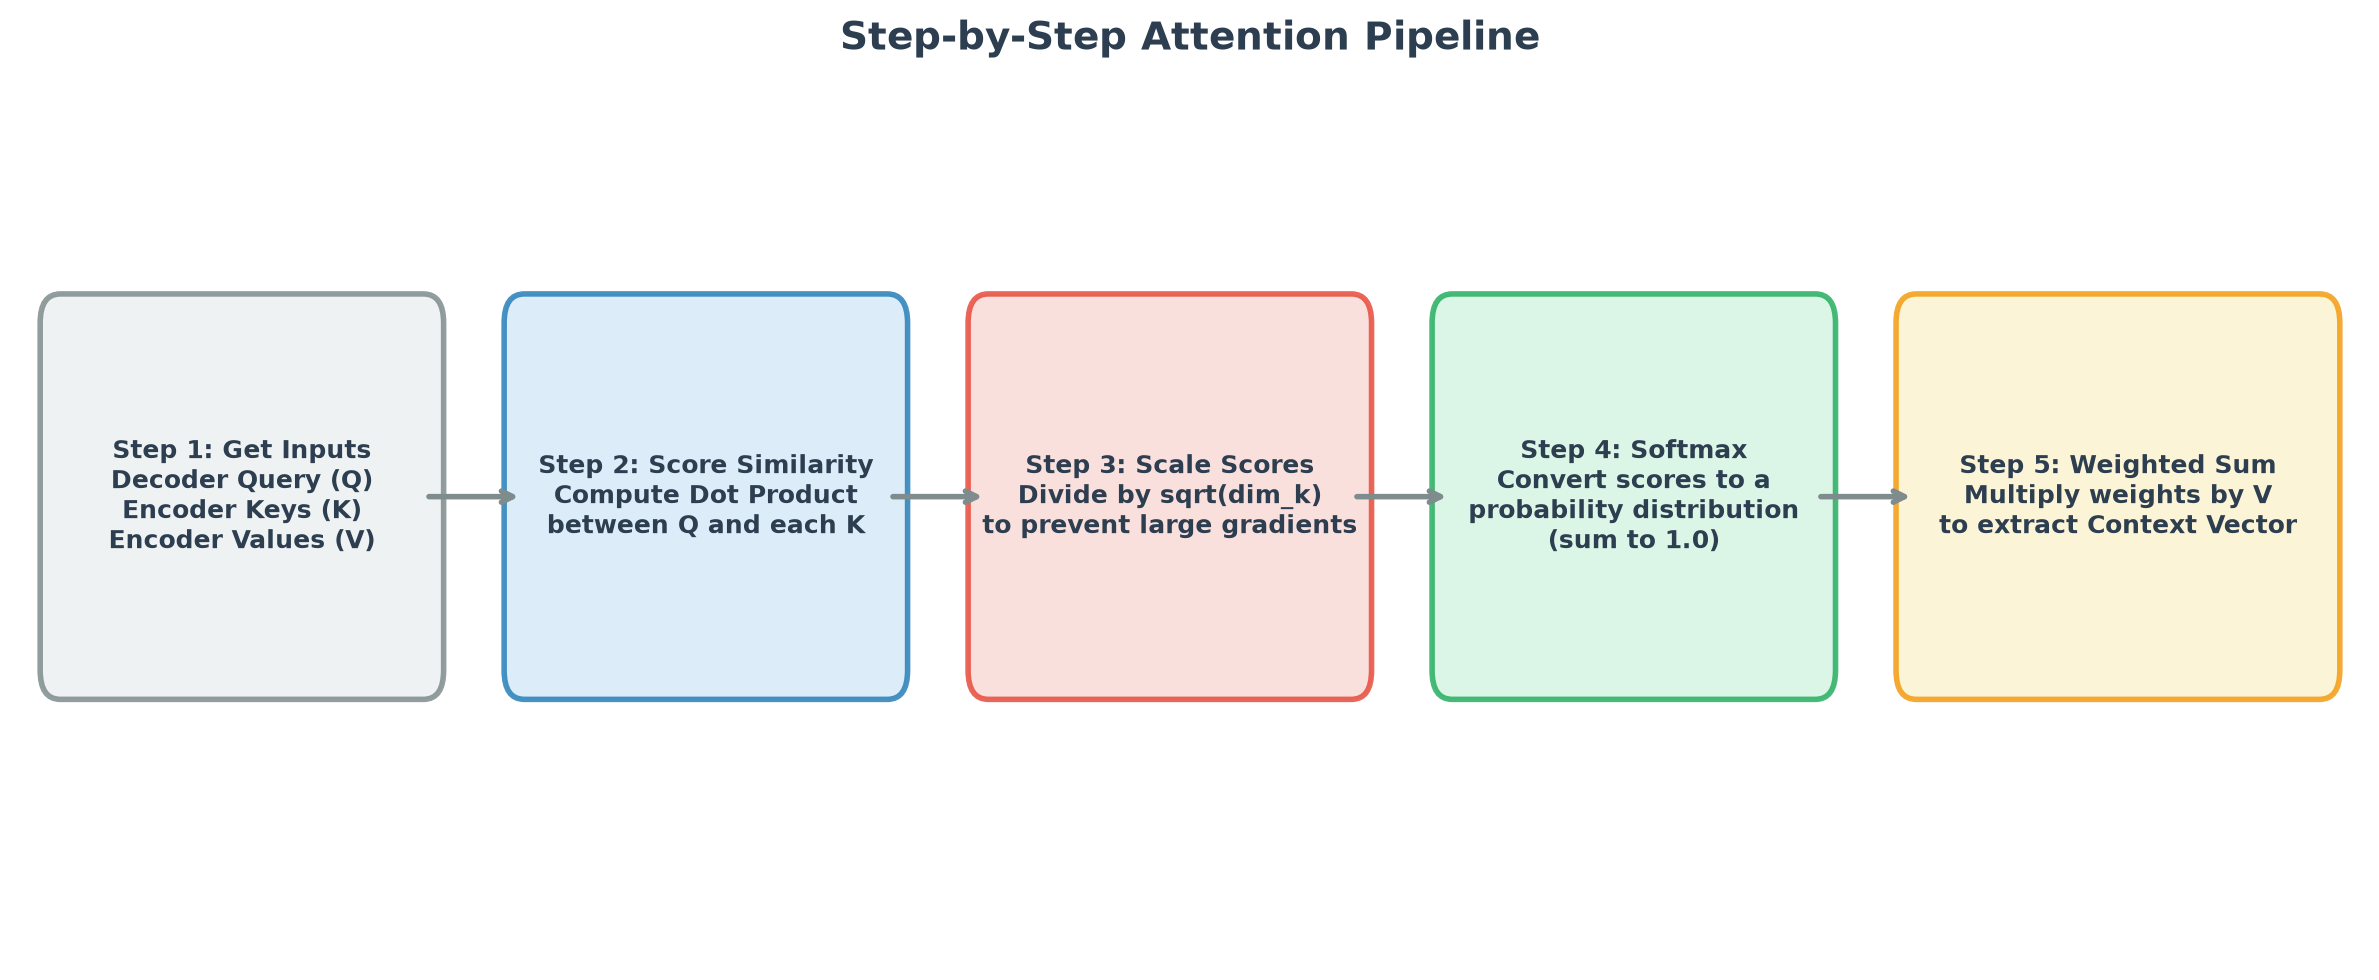

1. **Input Vectors**: Gather Queries ($Q$), Keys ($K$), and Values ($V$).
2. **Dot Product Similarity**: Multiply the Query matrix by the transpose of the Key matrix ($Q K^T$) to get raw compatibility scores.
3. **Scaling**: Divide the scores by $\sqrt{d_k}$ (the square root of the key dimension). This scaling factor is critical: if $d_k$ is large, the dot products can grow extremely large in magnitude, pushing the subsequent Softmax function into regions with very small gradients (vanishing gradients).
4. **Softmax**: Apply Softmax across the scaled scores to produce attention weights (probabilities summing to $1.0$).
5. **Weighted Sum**: Multiply the attention weights by the Value matrix ($V$) to compute the final Context Vector.

Mathematically, this is expressed as:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

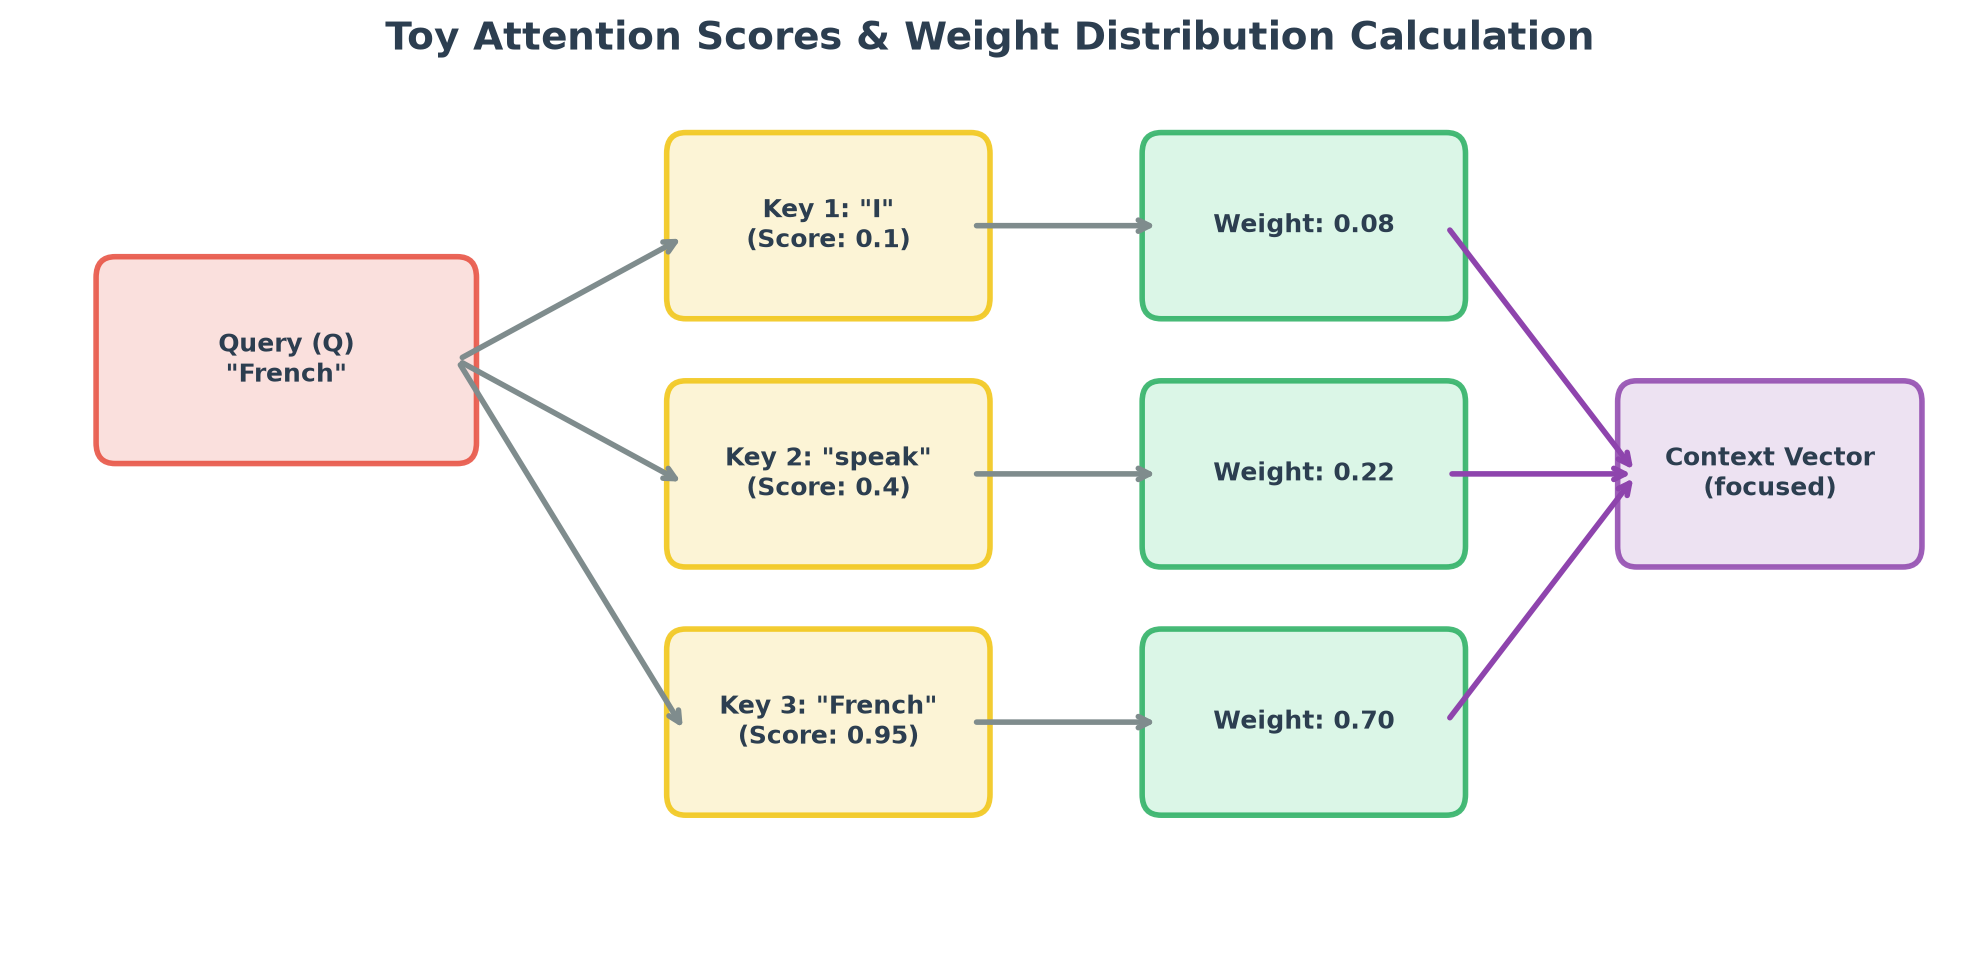


### NumPy Implementation of Scaled Dot-Product Attention from Scratch
Below, we write the attention mechanism calculations by hand using NumPy. We simulate a toy sentence query search to observe output weights.

In [1]:
import numpy as np

def scaled_dot_product_attention_scratch(q, k, v):
    """
    Computes Scaled Dot-Product Attention weights and context vectors.
    q: Query tensor (batch_size, num_queries, d_k)
    k: Key tensor (batch_size, seq_len, d_k)
    v: Value tensor (batch_size, seq_len, d_v)
    """
    d_k = q.shape[-1]
    # 1. Similarity scores
    scores = np.matmul(q, k.swapaxes(-2, -1))
    
    # 2. Scaling
    scaled_scores = scores / np.sqrt(d_k)
    
    # 3. Softmax activation
    # Subtract max for numerical stability
    exp_scores = np.exp(scaled_scores - np.max(scaled_scores, axis=-1, keepdims=True))
    attention_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)
    
    # 4. Weighted values sum
    context = np.matmul(attention_weights, v)
    
    return context, attention_weights

# --- Toy Simulation ---
# Let's simulate a 3-word sequence with embedding dimension of 4
np.random.seed(42)
Q = np.random.randn(1, 1, 4) # 1 query step (representing decoder)
K = np.random.randn(1, 3, 4) # 3 key steps (representing encoder)
V = np.random.randn(1, 3, 4) # 3 value steps

context, weights = scaled_dot_product_attention_scratch(Q, K, V)
print("Attention Weights (probability distribution over 3 source tokens):")
print(weights)
print("\nGenerated Context Vector:")
print(context)


Attention Weights (probability distribution over 3 source tokens):
[[[0.74744999 0.13482285 0.11772716]]]

Generated Context Vector:
[[[-0.6235263   0.21750296 -0.80510145 -1.20348514]]]
